# Using Image data for node features
Next, we will try to include some kind of image data for the node features

In [1]:
%load_ext autoreload
%autoreload 2

import torch
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool
print(torch.__version__)

2.9.0+cu128


## Load colmap data and images
Let's see what it takes to load the image data associated with the colmap model

In [2]:
import pycolmap
import pathlib
import utils.subset

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

In [3]:
image = reconstruction.images[1]
image.name

'r_1.png'

In [4]:
# Check directory for images
import os
image_dir = pathlib.Path('data', '01_nerf', '02_lego_large')
os.listdir(image_dir)

['r_0.png',
 'r_1.png',
 'r_10.png',
 'r_11.png',
 'r_12.png',
 'r_13.png',
 'r_14.png',
 'r_15.png',
 'r_16.png',
 'r_17.png',
 'r_18.png',
 'r_19.png',
 'r_2.png',
 'r_20.png',
 'r_21.png',
 'r_22.png',
 'r_23.png',
 'r_24.png',
 'r_25.png',
 'r_26.png',
 'r_27.png',
 'r_28.png',
 'r_29.png',
 'r_3.png',
 'r_30.png',
 'r_31.png',
 'r_32.png',
 'r_33.png',
 'r_34.png',
 'r_35.png',
 'r_36.png',
 'r_37.png',
 'r_38.png',
 'r_39.png',
 'r_4.png',
 'r_40.png',
 'r_41.png',
 'r_42.png',
 'r_43.png',
 'r_44.png',
 'r_45.png',
 'r_46.png',
 'r_47.png',
 'r_48.png',
 'r_49.png',
 'r_5.png',
 'r_50.png',
 'r_51.png',
 'r_52.png',
 'r_53.png',
 'r_54.png',
 'r_55.png',
 'r_56.png',
 'r_57.png',
 'r_58.png',
 'r_59.png',
 'r_6.png',
 'r_60.png',
 'r_61.png',
 'r_62.png',
 'r_63.png',
 'r_64.png',
 'r_65.png',
 'r_66.png',
 'r_67.png',
 'r_68.png',
 'r_7.png',
 'r_8.png',
 'r_9.png']

In [5]:
image_path = image_dir / reconstruction.images[1].name

In [6]:
image_path

WindowsPath('data/01_nerf/02_lego_large/r_1.png')

In [7]:
from PIL import Image
print(f"loading image from {image_path}")
img = Image.open(image_path)

loading image from data\01_nerf\02_lego_large\r_1.png


In [8]:
print(img.format, img.size, img.mode)

PNG (800, 800) RGBA


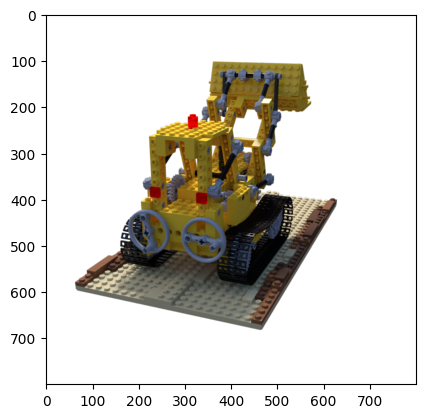

In [9]:
from matplotlib import pyplot as plt
plt.imshow(img)
plt.show()

In [16]:
# To start, let's try downsampling to a very small array, and pass that into our GCN.
small_img = img.resize((10,10), resample=Image.LANCZOS)

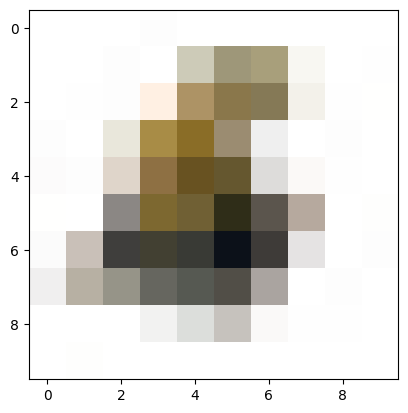

In [17]:
plt.imshow(small_img)
plt.show()

In [44]:
from torchvision import transforms

filtered_image_ids = [2, 3, 4, 7]

# 2. Load images as tensors
image_tensors = []
transform = transforms.ToTensor()
for image_id in filtered_image_ids:
    image = reconstruction.images[image_id]
    image_path = image_dir / image.name
    img = Image.open(image_path).convert("RGB")
    img = img.resize((5, 5), resample=Image.LANCZOS) # Resize to 5x5 for now as a quick experiment
    image_tensors.append(transform(img))
    # image_tensors.append(img)


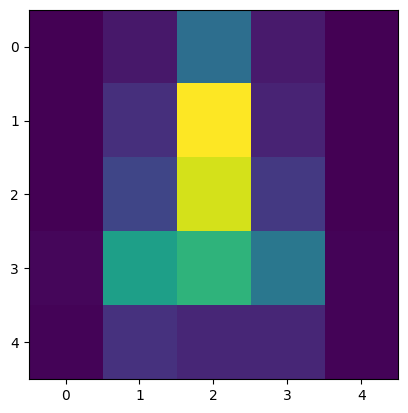

In [45]:
# Example if taking 1st image, and 1st channel
plt.imshow(image_tensors[0][0])
plt.show()

In [46]:
temp = torch.stack(image_tensors)
temp

tensor([[[[0.0000, 0.0314, 0.1804, 0.0353, 0.0000],
          [0.0000, 0.0667, 0.5020, 0.0510, 0.0000],
          [0.0000, 0.1059, 0.4706, 0.0824, 0.0000],
          [0.0078, 0.2824, 0.3255, 0.2000, 0.0039],
          [0.0039, 0.0706, 0.0549, 0.0549, 0.0039]],

         [[0.0000, 0.0275, 0.1569, 0.0314, 0.0000],
          [0.0000, 0.0549, 0.4000, 0.0471, 0.0000],
          [0.0000, 0.0824, 0.3765, 0.0706, 0.0000],
          [0.0039, 0.2510, 0.3216, 0.1922, 0.0000],
          [0.0039, 0.0667, 0.0588, 0.0549, 0.0000]],

         [[0.0000, 0.0118, 0.0824, 0.0118, 0.0000],
          [0.0000, 0.0235, 0.1608, 0.0235, 0.0000],
          [0.0000, 0.0549, 0.1608, 0.0549, 0.0000],
          [0.0039, 0.2157, 0.2706, 0.1765, 0.0000],
          [0.0039, 0.0588, 0.0549, 0.0510, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000, 0.2353, 0.0275],
          [0.0000, 0.3020, 0.2627, 0.3333, 0.0667],
          [0.0588, 0.2471, 0.4039, 0.2314, 0.0784],
          [0.0392, 0.0314, 0.1765, 0.5137, 0.2784],
    

In [47]:
print(temp.shape)

torch.Size([4, 3, 5, 5])


In [48]:
temp2 = temp.view(temp.size(0), -1)
temp2

tensor([[0.0000, 0.0314, 0.1804, 0.0353, 0.0000, 0.0000, 0.0667, 0.5020, 0.0510,
         0.0000, 0.0000, 0.1059, 0.4706, 0.0824, 0.0000, 0.0078, 0.2824, 0.3255,
         0.2000, 0.0039, 0.0039, 0.0706, 0.0549, 0.0549, 0.0039, 0.0000, 0.0275,
         0.1569, 0.0314, 0.0000, 0.0000, 0.0549, 0.4000, 0.0471, 0.0000, 0.0000,
         0.0824, 0.3765, 0.0706, 0.0000, 0.0039, 0.2510, 0.3216, 0.1922, 0.0000,
         0.0039, 0.0667, 0.0588, 0.0549, 0.0000, 0.0000, 0.0118, 0.0824, 0.0118,
         0.0000, 0.0000, 0.0235, 0.1608, 0.0235, 0.0000, 0.0000, 0.0549, 0.1608,
         0.0549, 0.0000, 0.0039, 0.2157, 0.2706, 0.1765, 0.0000, 0.0039, 0.0588,
         0.0549, 0.0510, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.2353, 0.0275, 0.0000, 0.3020, 0.2627, 0.3333,
         0.0667, 0.0588, 0.2471, 0.4039, 0.2314, 0.0784, 0.0392, 0.0314, 0.1765,
         0.5137, 0.2784, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0078, 0.1725, 0.0196, 0.0000, 0.2275, 0.2078, 0.2431, 0.0431, 0.

In [49]:
temp2.shape

torch.Size([4, 75])

# Load dataset with images


In [81]:
## Load the colmap data
import pycolmap
import pathlib
import utils.subset
import random
import utils.loaders

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

random.seed(42) # for reproducibility

# Sample images into disjoint sets
a_ids, b_ids = utils.subset.sample_image_subsets(reconstruction)

image_dir = pathlib.Path('data', '01_nerf', '02_lego_large')

# Convert the reconstruction data into two sub-graphs
graph_a = utils.loaders.loaders.load_reconstruction_to_graph(reconstruction, image_dir, a_ids)
graph_b = utils.loaders.loaders.load_reconstruction_to_graph(reconstruction, image_dir, b_ids)
graph_a.x

tensor([[ 3.2962e-01,  4.1331e+00, -4.8782e-01,  ...,  9.0196e-02,
          0.0000e+00,  0.0000e+00],
        [-1.2084e+00,  4.3559e+00, -5.2545e-01,  ...,  5.4902e-02,
          5.0980e-02,  0.0000e+00],
        [ 2.9589e+00, -1.2564e+00,  2.5346e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        ...,
        [-3.2780e+00, -2.4664e+00,  6.0880e-01,  ...,  7.4510e-02,
          0.0000e+00,  0.0000e+00],
        [-1.5672e+00, -3.4255e+00,  3.4595e+00,  ...,  3.9216e-03,
          3.9216e-03,  0.0000e+00],
        [ 8.5093e-01,  1.3613e+00, -1.6269e+00,  ...,  8.2353e-02,
          0.0000e+00,  3.9216e-03]])

In [73]:
graph_a.image_tensors[0]

tensor([[[0.0000, 0.0000, 0.1451, 0.1098, 0.0000],
         [0.0000, 0.1765, 0.4549, 0.0941, 0.0000],
         [0.0000, 0.3137, 0.3569, 0.1451, 0.0078],
         [0.1373, 0.3137, 0.2431, 0.1020, 0.0000],
         [0.0157, 0.0431, 0.1020, 0.0039, 0.0000]],

        [[0.0000, 0.0000, 0.1294, 0.0980, 0.0000],
         [0.0000, 0.1294, 0.3608, 0.0824, 0.0000],
         [0.0000, 0.2549, 0.2980, 0.1333, 0.0039],
         [0.1176, 0.3059, 0.2431, 0.0902, 0.0000],
         [0.0157, 0.0431, 0.0980, 0.0039, 0.0000]],

        [[0.0000, 0.0000, 0.0706, 0.0431, 0.0000],
         [0.0000, 0.0353, 0.1569, 0.0392, 0.0000],
         [0.0000, 0.1255, 0.1412, 0.1255, 0.0039],
         [0.1020, 0.2706, 0.2275, 0.0824, 0.0000],
         [0.0118, 0.0392, 0.0902, 0.0000, 0.0000]]])

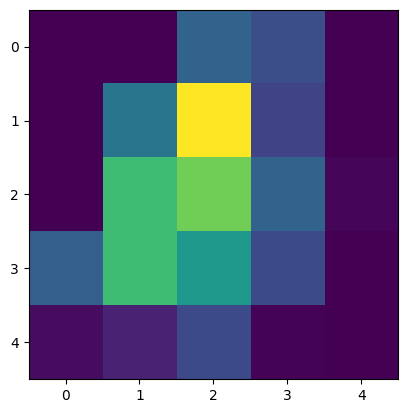

In [74]:
# Example if taking 1st image, and 1st channel
plt.imshow(graph_a.image_tensors[0][0])
plt.show()

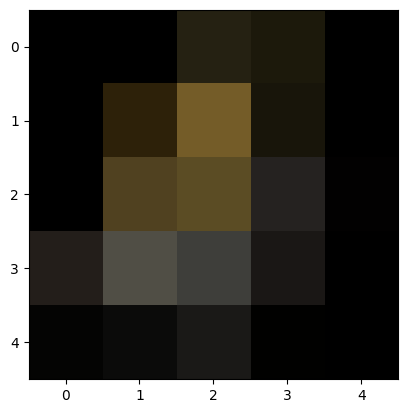

In [75]:
plt.imshow(graph_a.image_files[0])
plt.show()

In [77]:
graph_a.image_paths[0]

WindowsPath('data/01_nerf/02_lego_large/r_1.png')

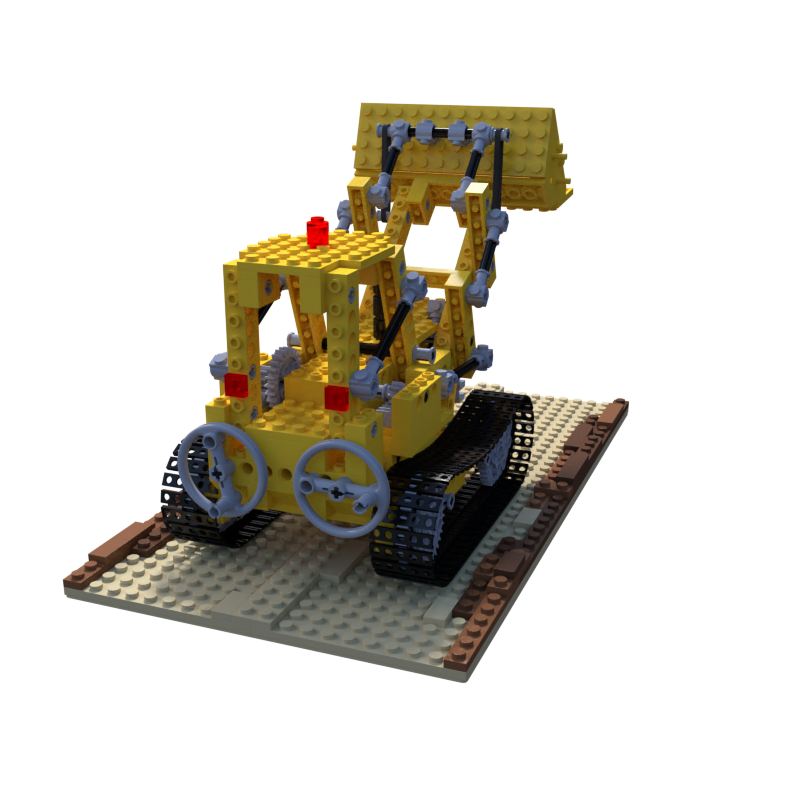

In [79]:
Image.open(graph_a.image_paths[0])